# Portfolio Optimization Project
## First import libraries

In [1]:
#import libraries here
import time
import pandas as pd
import numpy as np
import plotly
import plotly.express as px
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import csv
import nltk

from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.svm import SVC, SVR
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from scipy.optimize import minimize
from datetime import datetime, timedelta
from tqdm import tqdm

#from pandas_datareader import data as pdr


set_config(display="diagram")
plt.style.use('fivethirtyeight')

In [2]:
#py install PyPortfolioOpt
#pip install pandas_datareader

In [3]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns

## Identify the asset classes (stocks) you are interested in assessing 

In [4]:
assets = ["NVDA", "MSFT", "GOOG", "AMZN", "SPY", "BND", "GLD", "QQQ", "VTI"]
assets
stocks = assets[:4]
etf = assets[4:]

etf2 = ["IWV", "VCIT", "SPTL", "VEA", "IEMG", "TIP", "JNK"]
assets

['NVDA', 'MSFT', 'GOOG', 'AMZN', 'SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [5]:
stocks

['NVDA', 'MSFT', 'GOOG', 'AMZN']

In [6]:
etf

['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [7]:
etf2

['IWV', 'VCIT', 'SPTL', 'VEA', 'IEMG', 'TIP', 'JNK']

#### Grab data from Yahoo Finance


In [8]:
a_data = yf.download(assets, "2021-1-1")["Close"]
a_data.head(5)

[*********************100%***********************]  9 of 9 completed


Ticker,AMZN,BND,GLD,GOOG,MSFT,NVDA,QQQ,SPY,VTI
Date,,,,,,,,,
2021-01-04,159.331497,74.647911,182.330002,85.708344,208.406525,13.076015,299.785126,343.319183,178.250092
2021-01-05,160.925507,74.520767,182.869995,86.337173,208.607544,13.366436,302.256531,345.683685,179.690079
2021-01-06,156.919006,74.190208,179.899994,86.057976,203.198547,12.578445,298.069672,347.750397,181.306564
2021-01-07,158.108002,74.037590,179.479996,88.634811,208.980942,13.305859,305.280487,352.917114,184.214355
2021-01-08,159.134995,73.969841,173.339996,89.624680,210.254196,13.238800,309.205811,354.927917,185.106216


In [9]:
a_data.tail(5)

Ticker,AMZN,BND,GLD,GOOG,MSFT,NVDA,QQQ,SPY,VTI
Date,,,,,,,,,
2026-05-07,271.170013,73.360001,431.679993,395.299988,420.769989,211.500000,694.940002,731.580017,360.200012
2026-05-08,272.679993,73.550003,433.769989,397.049988,415.119995,215.199997,711.229980,737.619995,362.869995
2026-05-11,268.989990,73.370003,434.649994,386.769989,412.660004,219.440002,713.289978,739.299988,363.630005
2026-05-12,265.820007,73.150002,432.929993,383.820007,407.769989,220.779999,707.239990,738.179993,362.790009
2026-05-13,270.190002,73.147003,431.549988,397.799988,404.972198,227.029999,714.789978,742.700928,364.760010


In [10]:
a_data.shape


(1346, 9)

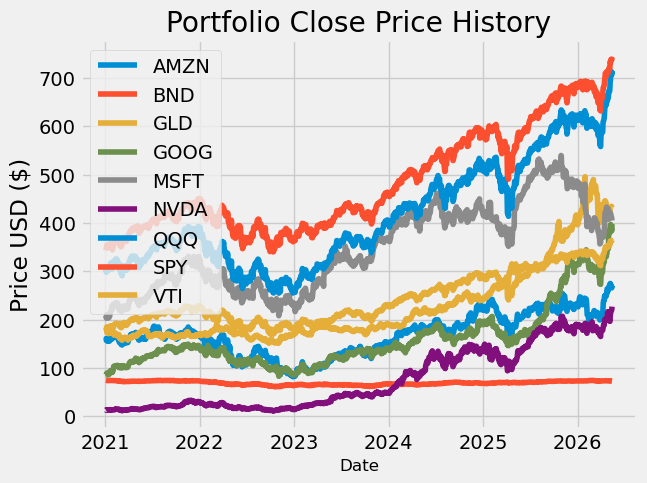

In [11]:
title = 'Portfolio Close Price History'

my_stocks = a_data

for c in my_stocks.columns.values:
    plt.plot(my_stocks[c], label =c)

plt.title(title)
plt.xlabel('Date', fontsize =12)
plt.ylabel('Price USD ($)')
plt.legend(my_stocks.columns.values, loc = 'upper left')
plt.show()

#### Log the data to make it easier to aggregate, more statistically stable, and aligned with financial theory

In [12]:
a_returns = np.log(a_data).diff().dropna()
a_returns.head(7)

Ticker,AMZN,BND,GLD,GOOG,MSFT,NVDA,QQQ,SPY,VTI
Date,,,,,,,,,
2021-01-05,0.009955,-0.001705,0.002957,0.007310,0.000964,0.021967,0.008210,0.006864,0.008046
2021-01-06,-0.025212,-0.004446,-0.016374,-0.003239,-0.026271,-0.060762,-0.013949,0.005961,0.008956
2021-01-07,0.007549,-0.002059,-0.002337,0.029503,0.028059,0.056220,0.023904,0.014748,0.015911
2021-01-08,0.006475,-0.000915,-0.034809,0.011106,0.006074,-0.005053,0.012776,0.005681,0.004830
2021-01-11,-0.021754,-0.001032,-0.001963,-0.022659,-0.009746,0.025635,-0.014556,-0.006764,-0.005990
2021-01-12,0.002124,-0.000229,0.006453,-0.011482,-0.011841,-0.010090,-0.001591,0.000211,0.003528
2021-01-13,0.014335,0.002635,-0.004317,0.004485,0.006539,0.003479,0.006731,0.002689,0.001106


In [13]:
#a_returns = a_returns.iloc[:-1]


In [14]:
a_returns.shape

(1345, 9)

In [15]:
a_returns.tail(5)

Ticker,AMZN,BND,GLD,GOOG,MSFT,NVDA,QQQ,SPY,VTI
Date,,,,,,,,,
2026-05-07,-0.013989,-0.002587,0.001669,0.000405,0.016317,0.017505,-0.001194,-0.003071,-0.004598
2026-05-08,0.005553,0.002587,0.004830,0.004417,-0.013519,0.017343,0.023170,0.008222,0.007385
2026-05-11,-0.013625,-0.002450,0.002027,-0.026232,-0.005944,0.019511,0.002892,0.002275,0.002092
2026-05-12,-0.011855,-0.003003,-0.003965,-0.007656,-0.011921,0.006088,-0.008518,-0.001516,-0.002313
2026-05-13,0.016306,-0.000041,-0.003193,0.035776,-0.006885,0.027915,0.010619,0.006106,0.005415


#### Get the *annual* covariance and expected returns amongst the assets chosen
Covariance measures the relationship between variable stocks. 
Positive covariance = move in the same direction. 
Negative covariance = move opposite.  
Near 0 = unrelated movements.

In [16]:
a_cov = a_returns.cov()*252
a_cov.head(10)

Ticker,AMZN,BND,GLD,GOOG,MSFT,NVDA,QQQ,SPY,VTI
Ticker,,,,,,,,,
AMZN,0.121231,0.003200,0.003561,0.066293,0.057407,0.097222,0.059937,0.041805,0.042515
BND,0.003200,0.003467,0.003100,0.002697,0.002226,0.003365,0.002613,0.001952,0.002050
GLD,0.003561,0.003100,0.031796,0.006109,0.003154,0.007107,0.005117,0.004096,0.004335
GOOG,0.066293,0.002697,0.006109,0.095420,0.048134,0.080917,0.050741,0.035683,0.035880
MSFT,0.057407,0.002226,0.003154,0.048134,0.068678,0.081206,0.045982,0.032173,0.032116
NVDA,0.097222,0.003365,0.007107,0.080917,0.081206,0.259214,0.090274,0.060137,0.061038
QQQ,0.059937,0.002613,0.005117,0.050741,0.045982,0.090274,0.050107,0.035757,0.036429
SPY,0.041805,0.001952,0.004096,0.035683,0.032173,0.060137,0.035757,0.028480,0.028987
VTI,0.042515,0.002050,0.004335,0.035880,0.032116,0.061038,0.036429,0.028987,0.029802


In [17]:
a_expected_returns = a_returns.mean() * 252
a_expected_returns.head(11)

Ticker
AMZN    0.098952
BND    -0.003806
GLD     0.161423
GOOG    0.287598
MSFT    0.124469
NVDA    0.534784
QQQ     0.162802
SPY     0.144574
VTI     0.134160
dtype: float64

In [18]:
a_portfolio_returns = sum(a_expected_returns)
a_portfolio_returns

1.6449565853352428

### Set up initial weights and calculate Expected Return
Evaluate an equally weighted portfolio by calculating its expected return, risk (volatility), and Sharpe ratio using the covariance matrix and expected asset returns. Weights array must be same size as number of assets assessed. Higher variance means higher fluctuations and higher risk while lower variance means more stable returns. Return porfolio metrics based on pre-optimized parameters. 


In [19]:
assets

['NVDA', 'MSFT', 'GOOG', 'AMZN', 'SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [20]:
a_weights = np.array([1/9,1/9,1/9,1/9,1/9,1/9,1/9,1/9,1/9])
s_weights = np.array([.3,.2,.2,.3])

In [21]:
#Getting the variance of the assets
a_var = np.dot(a_weights.T, np.dot(a_cov, a_weights))
a_var

np.float64(0.03751639240467904)

In [22]:
#Get the volitility of the assets
a_vol = np.sqrt(a_var)
a_vol

np.float64(0.19369148769287473)

In [23]:
exp_ret = np.dot(a_expected_returns, a_weights)
#std = np.dot(a_weights.T, np.dot(a_weights, a_cov)) ** .5
std = np.sqrt(a_weights.T @ a_cov @ a_weights)
rfr = .05
sharpe = (exp_ret - rfr ) / std

print(f"Expected Return:\t{exp_ret:>10.2%}")
print(f"Volatility:\t{std:>10.2%}")
print(f"Sharpe:\t\t{sharpe:>10.2f}")

Expected Return:	    18.28%
Volatility:	    19.37%
Sharpe:		      0.69


### Helper functions for optimization
Defines helper functions for portfolio optimization. The port_metrics() function calculates a portfolio’s expected return, volatility, and Sharpe ratio using asset weights and covariance data. The min_sharpe() function returns the negative Sharpe ratio so optimization algorithms can maximize it through minimization, while check_sum() ensures the portfolio weights add up to 1 as a constraint during optimization. Minimize the negative sharpe ratio has the same effect as maximizing the positive sharpe ratio. 

In [24]:
def port_metrics(a_weights):
    rfr = .05
    stock_returns = a_returns.mean() * 252
    exp_ret = np.dot(a_weights, stock_returns)
    std = np.sqrt(a_weights.T @ a_cov @ a_weights)
    sharpe = (exp_ret - rfr) / std
    return exp_ret, std, sharpe

def min_sharpe(a_weights):
    return -port_metrics(a_weights)[2]

def check_sum(a_weights):
    return np.sum(a_weights) - 1

In [25]:
print(port_metrics(a_weights))

(np.float64(0.18277295392613807), np.float64(0.19369148769287473), np.float64(0.6854867785241466))


#### Set bounds and constraints for the portfolio and then find optimal weights for investment
Bounds mean the minimum and maximum investment you want to put in an asset

In [26]:
bounds = [(0.05,.5) for weight in a_weights]
constraints = {"type": "eq", "fun": check_sum}

In [27]:
portfolio = minimize(min_sharpe, a_weights, method = "SLSQP", bounds = bounds, constraints = constraints)

In [28]:
assets

['NVDA', 'MSFT', 'GOOG', 'AMZN', 'SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [29]:
portfolio.x.round(3)

array([0.05 , 0.05 , 0.377, 0.075, 0.05 , 0.248, 0.05 , 0.05 , 0.05 ])

In [30]:
a_data.head(1)

Ticker,AMZN,BND,GLD,GOOG,MSFT,NVDA,QQQ,SPY,VTI
Date,,,,,,,,,
2021-01-04,159.331497,74.647911,182.330002,85.708344,208.406525,13.076015,299.785126,343.319183,178.250092


In [31]:
port_metrics(portfolio.x)

(np.float64(0.24795291025828817),
 np.float64(0.202304438647621),
 np.float64(0.9784901981468017))

In [32]:
portfolio.success

True

## Claude Document generation validation check
Validate the results generated by Claude in the constrained optimization 

inputs are expected returns, use that as input to achieve optimal mix of etfs

for smp 500, they look at historical dataset and come up with X stock over 10 or 20 years. use average as input going forward
take expected return and return the best optimal profile + weights

In [33]:
assets

['NVDA', 'MSFT', 'GOOG', 'AMZN', 'SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [34]:
a1_weights = np.array([.050, .050, .382, .085, .050, .233, .050, .050, .050])
#Getting the variance of the assets
a1_var = np.dot(a1_weights.T, np.dot(a_cov, a1_weights))
a1_var


np.float64(0.03923907723513496)

In [35]:
a_data.head()

Ticker,AMZN,BND,GLD,GOOG,MSFT,NVDA,QQQ,SPY,VTI
Date,,,,,,,,,
2021-01-04,159.331497,74.647911,182.330002,85.708344,208.406525,13.076015,299.785126,343.319183,178.250092
2021-01-05,160.925507,74.520767,182.869995,86.337173,208.607544,13.366436,302.256531,345.683685,179.690079
2021-01-06,156.919006,74.190208,179.899994,86.057976,203.198547,12.578445,298.069672,347.750397,181.306564
2021-01-07,158.108002,74.037590,179.479996,88.634811,208.980942,13.305859,305.280487,352.917114,184.214355
2021-01-08,159.134995,73.969841,173.339996,89.624680,210.254196,13.238800,309.205811,354.927917,185.106216


In [36]:
a1_vol = np.sqrt(a1_var)
a1_vol

np.float64(0.19808855907178222)

In [37]:
exp1_ret = np.dot(a_expected_returns, a1_weights)
#std = np.dot(a_weights.T, np.dot(a_weights, a_cov)) ** .5
std1 = np.sqrt(a1_weights.T @ a_cov @ a1_weights)
rfr = .05
sharpe1 = (exp1_ret - rfr ) / std1

print(f"Expected Return:\t{exp1_ret:>10.2%}")
print(f"Volatility:\t{std1:>10.2%}")
print(f"Sharpe:\t\t{sharpe1:>10.2f}")

Expected Return:	    24.38%
Volatility:	    19.81%
Sharpe:		      0.98


# Measuring ETFs Only

In [38]:
etf_data = yf.download(etf2, "2021-1-1")["Close"]
etf_data.head(5)

[*********************100%***********************]  7 of 7 completed


Ticker,IEMG,IWV,JNK,SPTL,TIP,VCIT,VEA
Date,,,,,,,
2021-01-04,54.129833,206.884125,78.873459,38.137516,104.808105,79.250008,40.351166
2021-01-05,55.298290,208.637939,78.924255,37.883598,104.775307,79.103004,40.810093
2021-01-06,54.891495,210.241684,78.808121,37.130341,104.463661,78.841591,41.252014
2021-01-07,55.324257,213.683670,79.025841,36.817184,104.398056,78.759941,41.370983
2021-01-08,56.726410,214.818497,79.127487,36.707157,103.987984,78.637390,41.761925


In [39]:
etf_returns = np.log(etf_data).diff().dropna()

In [74]:
etf_returns.head(10)

Ticker,IEMG,IWV,JNK,SPTL,TIP,VCIT,VEA
Date,,,,,,,
2021-01-05,0.021357,0.008442,0.000644,-0.006680,-0.000313,-0.001857,0.011309
2021-01-06,-0.007384,0.007657,-0.001473,-0.020084,-0.002979,-0.003310,0.010771
2021-01-07,0.007853,0.016239,0.002759,-0.008470,-0.000628,-0.001036,0.002880
2021-01-08,0.025028,0.005297,0.001285,-0.002993,-0.003936,-0.001557,0.009405
2021-01-11,-0.013363,-0.006087,-0.005427,-0.002078,-0.002132,-0.002496,-0.013110
2021-01-12,0.009235,0.003201,0.001475,-0.000693,0.001343,0.001145,0.004731
2021-01-13,0.001990,0.001050,0.002759,0.010579,0.002208,0.003634,-0.001849
2021-01-14,0.009284,-0.001488,-0.000368,-0.008732,0.000472,-0.001244,0.007578
2021-01-15,-0.013421,-0.007916,-0.001471,0.003916,0.001101,0.000726,-0.016250


In [40]:
etf_cov = etf_returns.cov()*252
etf_cov.head(10)

Ticker,IEMG,IWV,JNK,SPTL,TIP,VCIT,VEA
Ticker,,,,,,,
IEMG,0.033868,0.022059,0.008038,0.002172,0.001784,0.003624,0.024911
IWV,0.022059,0.029267,0.009655,0.001804,0.002094,0.003926,0.022974
JNK,0.008038,0.009655,0.005436,0.004180,0.002095,0.003220,0.008549
SPTL,0.002172,0.001804,0.004180,0.021039,0.006742,0.007965,0.002729
TIP,0.001784,0.002094,0.002095,0.006742,0.003775,0.003162,0.002355
VCIT,0.003624,0.003926,0.003220,0.007965,0.003162,0.004215,0.004137
VEA,0.024911,0.022974,0.008549,0.002729,0.002355,0.004137,0.026709


In [71]:
etf_expected_returns = etf_returns.mean() * 252
etf_expected_returns

Ticker
IEMG    0.078194
IWV     0.132819
JNK     0.037304
SPTL   -0.073405
TIP     0.010915
VCIT    0.007576
VEA     0.104652
dtype: float64

In [92]:
#Expected Returns:
#Emerging Market Equity:     IEMG 8%
#US Equity:                  IWV  8%
#High Yield Bonds:           JNK  6.6%
#Long Term Government Bonds  SPTL 5.1%
#TIPS:                       TIP  4.7% 
#Investment Grade Bonds:     VCIT 4.9%
#Developed Non-US Equity:    VEA  7.9%
etf_desired_returns = {
    "IEMG": 0.078194,
    "IWV": 0.132819,
"JNK":     0.037304,
"SPTL":   -0.073405,
"TIP":     0.010915,
"VCIT":    0.007576,
"VEA":     0.104652
}
float_etf_dr= {k: float(v) for k, v in etf_desired_returns.items()}
float_etf_dr

{'IEMG': 0.078194,
 'IWV': 0.132819,
 'JNK': 0.037304,
 'SPTL': -0.073405,
 'TIP': 0.010915,
 'VCIT': 0.007576,
 'VEA': 0.104652}

In [93]:
etf_portfolio_returns = sum(etf_expected_returns)
etf_portfolio_returns

0.2980537923932246

In [94]:
etf_weights = np.array([1/7,1/7,1/7,1/7,1/7,1/7,1/7])

In [95]:
#Getting the variance of the etfs
etf_var = np.dot(etf_weights.T, np.dot(etf_cov, etf_weights))
etf_var

np.float64(0.008584908707962137)

In [96]:
#Get the volitility of the etfs
etf_vol = np.sqrt(etf_var)
etf_vol

np.float64(0.09265478243437916)

In [101]:
etf_exp_ret = np.dot(float_etf_dr, etf_weights)
etf_std = np.sqrt(etf_weights.T @ etf_cov @ etf_weights)
rfr = .05
etf_sharpe = (etf_exp_ret - rfr ) / etf_std

print(f"Expected Return:\t{etf_exp_ret:>10.2%}")
print(f"Volatility:\t{etf_std:>10.2%}")
print(f"Sharpe:\t\t{etf_sharpe:>10.2f}")

TypeError: unsupported operand type(s) for *: 'dict' and 'float'

In [98]:
def etf_port_metrics(etf_weights):
    rfr = .05
    etf_stock_returns = etf_returns.mean() * 252
    etf_exp_ret = np.dot(etf_weights, etf_stock_returns)
    etf_std = np.sqrt(etf_weights.T @ etf_cov @ etf_weights)
    etf_sharpe = (etf_exp_ret - rfr) / etf_std
    
    return etf_exp_ret, etf_std, etf_sharpe
    

def etf_min_sharpe(etf_weights):
    return -etf_port_metrics(etf_weights)[2]


In [99]:
etf_bounds = [(0.04,.24) for weight in etf_weights]
etf_constraints = {"type": "eq", "fun": check_sum}

In [100]:
etf_portfolio = minimize(etf_min_sharpe, etf_weights, method = "SLSQP", bounds = etf_bounds, constraints = etf_constraints)
etf_portfolio.x.round(3)

array([0.24, 0.24, 0.16, 0.04, 0.04, 0.04, 0.24])

In [63]:
etf_port_metrics(etf_portfolio.x)

(np.float64(0.0799008075964814),
 np.float64(0.12883025508799215),
 np.float64(0.23209460833605344))